# 🎬 Hybrid Movie Recommendation System

**Internship Project — Data Science & Analytics**

---

## 📍 Phase 1: Problem Understanding

### Problem Statement
With thousands of movies available on streaming platforms, users often struggle to find movies that match their taste. A **Movie Recommendation System** helps solve this by automatically suggesting movies similar to ones a user already likes — saving time and improving the viewing experience.

This project builds a **Hybrid Movie Recommendation System** that recommends movies using:
- **Content** — movie genres and user-generated tags (what the movie is *about*)
- **Ratings** — how well the movie has actually been received by users (how *good* it is)

Combining both gives more balanced recommendations than using genres alone — a movie isn't just recommended because it *sounds* similar, but also because it's actually well-liked.

### Project Objectives
- Understand and clean the MovieLens dataset (`movies.csv`, `ratings.csv`, `tags.csv`)
- Perform Exploratory Data Analysis (EDA) to understand genres, ratings, and release trends
- Engineer a combined text feature from **genres + tags**
- Convert this text into numeric vectors using **TF-IDF**
- Build a similarity matrix using **Cosine Similarity**
- Combine content similarity with **average rating** to build a hybrid recommendation score
- Test and evaluate the recommender on multiple movies


---
## 📍 Phase 2: Dataset Collection & Understanding

**Dataset:** MovieLens `ml-latest-small` (from Kaggle / GroupLens)

**Files used:**
| File | Description |
|---|---|
| `movies.csv` | Movie titles and genres |
| `ratings.csv` | User ratings for movies (0.5 to 5.0) |
| `tags.csv` | Free-text tags added by users for movies |

**Primary key:** `movieId` — this column links all three files together.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import difflib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")
%matplotlib inline


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import difflib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")


In [5]:
movies = pd.read_csv("data/movies.csv")
ratings = pd.read_csv("data/ratings.csv")
tags = pd.read_csv("data/tags.csv")

print("movies.csv  ->", movies.shape)
print("ratings.csv ->", ratings.shape)
print("tags.csv    ->", tags.shape)


movies.csv  -> (9742, 3)
ratings.csv -> (100836, 4)
tags.csv    -> (3683, 4)


### 2.1 A Quick Look at Each File

In [7]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [9]:
tags.head()


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


### 2.2 Understanding the Relationship Between Files

- `movies.csv` has **one row per movie** (`movieId` is unique here).
- `ratings.csv` has **one row per (user, movie) rating** — the same `movieId` can appear many times (once per user who rated it).
- `tags.csv` has **one row per (user, movie, tag)** — a movie can have multiple tags from multiple users.

So `movieId` is the common key we'll use to merge everything together.


In [11]:
print("Unique movies in movies.csv:", movies['movieId'].nunique())
print("Unique movies rated in ratings.csv:", ratings['movieId'].nunique())
print("Unique movies tagged in tags.csv:", tags['movieId'].nunique())
print("Unique users who rated:", ratings['userId'].nunique())
print("Unique users who tagged:", tags['userId'].nunique())


Unique movies in movies.csv: 9742
Unique movies rated in ratings.csv: 9724
Unique movies tagged in tags.csv: 1572
Unique users who rated: 610
Unique users who tagged: 58


In [12]:
movies.info()


<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [13]:
ratings.info()


<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


---
## 📍 Phase 3: Data Cleaning & Preprocessing


### 3.1 Checking for Missing Values & Duplicates

In [16]:
print("Missing values:")
print("movies:\n", movies.isnull().sum())
print("\nratings:\n", ratings.isnull().sum())
print("\ntags:\n", tags.isnull().sum())

print("\nDuplicate rows:")
print("movies:", movies.duplicated().sum())
print("ratings:", ratings.duplicated().sum())
print("tags:", tags.duplicated().sum())


Missing values:
movies:
 movieId    0
title      0
genres     0
dtype: int64

ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

tags:
 userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Duplicate rows:
movies: 0
ratings: 0
tags: 0


### 3.2 Cleaning Genres
Some movies have `(no genres listed)` instead of real genres. We'll keep these rows (so we don't lose ratings/tags data for them) but treat their genre text as empty during feature engineering.


In [18]:
print("Movies with no genres listed:", (movies['genres'] == '(no genres listed)').sum())

# Extract release year from the title, e.g. "Toy Story (1995)" -> 1995
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['clean_title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

# Replace '|' with spaces so genres can later be used as text features
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)
movies.loc[movies['genres'] == '(no genres listed)', 'genres_clean'] = ''

movies[['movieId', 'clean_title', 'year', 'genres_clean']].head()


Movies with no genres listed: 34


,movieId,clean_title,year,genres_clean
0,1,Toy Story,1995,Adventure Animation Children Comedy Fantasy
1,2,Jumanji,1995,Adventure Children Fantasy
2,3,Grumpier Old Men,1995,Comedy Romance
3,4,Waiting to Exhale,1995,Comedy Drama Romance
4,5,Father of the Bride Part II,1995,Comedy


### 3.3 Cleaning Tags
Tags are free text typed by users, so they can have inconsistent casing (e.g. `"Funny"` vs `"funny"`). We lowercase them and group **all tags for a movie into a single string**, since one movie can have multiple tags from different users.


In [20]:
tags['tag'] = tags['tag'].astype(str).str.lower().str.strip()

tags_grouped = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
tags_grouped.columns = ['movieId', 'all_tags']

print("Movies that have at least one tag:", tags_grouped.shape[0], "out of", movies.shape[0])
tags_grouped.head()


Movies that have at least one tag: 1572 out of 9742


,movieId,all_tags
0,1,pixar pixar fun
1,2,fantasy magic board game robin williams game
2,3,moldy old
3,5,pregnancy remake
4,7,remake


### 3.4 Preparing Rating Statistics
We summarize `ratings.csv` into one row per movie — the **average rating** and the **number of ratings** it received. This will be used both in EDA and later in our hybrid recommendation score.


In [22]:
rating_stats = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
rating_stats.columns = ['movieId', 'avg_rating', 'rating_count']
rating_stats['avg_rating'] = rating_stats['avg_rating'].round(2)

rating_stats.head()


,movieId,avg_rating,rating_count
0,1,3.92,215
1,2,3.43,110
2,3,3.26,52
3,4,2.36,7
4,5,3.07,49


### 3.5 Merging Everything Using `movieId`
Now we merge `movies`, `tags_grouped`, and `rating_stats` into a single clean dataframe.


In [24]:
df = movies.merge(tags_grouped, on='movieId', how='left')
df = df.merge(rating_stats, on='movieId', how='left')

# Movies with no tags -> empty string; movies with no ratings -> 0
df['all_tags'] = df['all_tags'].fillna('')
df['avg_rating'] = df['avg_rating'].fillna(0)
df['rating_count'] = df['rating_count'].fillna(0).astype(int)

print("Final merged shape:", df.shape)
df.head()


Final merged shape: (9742, 9)


,movieId,title,genres,year,clean_title,genres_clean,all_tags,avg_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,Toy Story,Adventure Animation Children Comedy Fantasy,pixar pixar fun,3.92,215
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,Jumanji,Adventure Children Fantasy,fantasy magic board game robin williams game,3.43,110
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men,Comedy Romance,moldy old,3.26,52
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,Waiting to Exhale,Comedy Drama Romance,,2.36,7
4,5,Father of the Bride Part II (1995),Comedy,1995,Father of the Bride Part II,Comedy,pregnancy remake,3.07,49


### 3.6 Creating the Combined Feature Column
This is the key step for content-based filtering — we combine **genres + tags** into a single text field per movie, which will later be converted into numeric vectors.


In [26]:
df['combined_features'] = (df['genres_clean'] + ' ' + df['all_tags']).str.strip()

print("Movies with no content at all (no genres, no tags):", (df['combined_features'] == '').sum())
df[['title', 'genres_clean', 'all_tags', 'combined_features']].head()


Movies with no content at all (no genres, no tags): 33


,title,genres_clean,all_tags,combined_features
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy,pixar pixar fun,Adventure Animation Children Comedy Fantasy pi...
1,Jumanji (1995),Adventure Children Fantasy,fantasy magic board game robin williams game,Adventure Children Fantasy fantasy magic board...
2,Grumpier Old Men (1995),Comedy Romance,moldy old,Comedy Romance moldy old
3,Waiting to Exhale (1995),Comedy Drama Romance,,Comedy Drama Romance
4,Father of the Bride Part II (1995),Comedy,pregnancy remake,Comedy pregnancy remake


---
## 📍 Phase 4: Exploratory Data Analysis (EDA)

Before building the model, let's explore the data visually to understand genre popularity, rating patterns, and release trends.


### 4.1 Top 10 Movie Genres

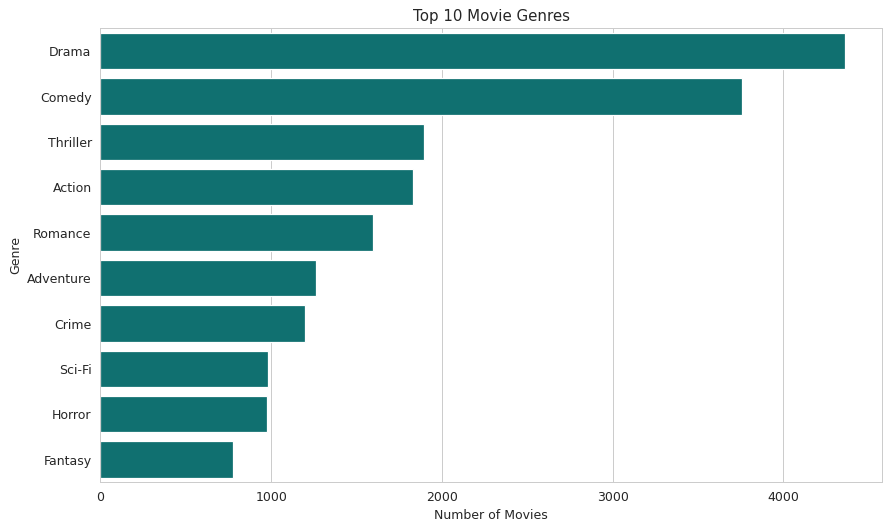

In [29]:
genre_counts = movies['genres'].str.split('|').explode()
genre_counts = genre_counts[genre_counts != '(no genres listed)'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="teal")
plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


### 4.2 Top 10 Most Rated Movies

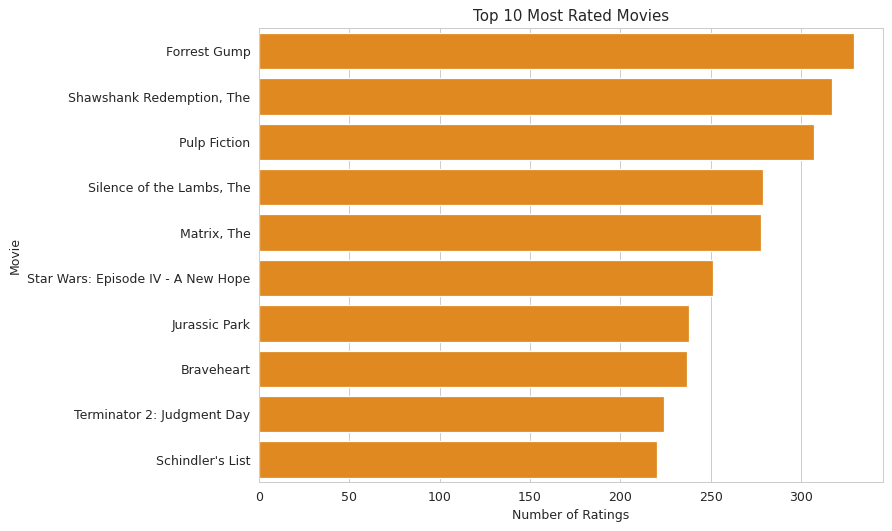

In [31]:
top_rated_count = df.sort_values('rating_count', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_rated_count['rating_count'], y=top_rated_count['clean_title'], color="darkorange")
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()


### 4.3 Distribution of User Ratings

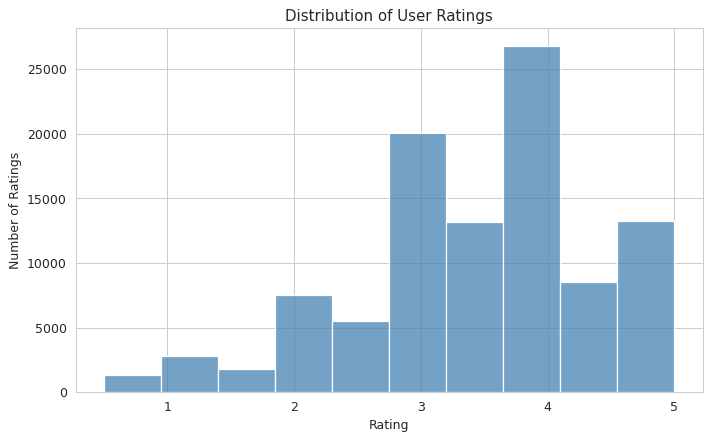

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(ratings['rating'], bins=10, color="steelblue")
plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()


### 4.4 Movies Released Per Year

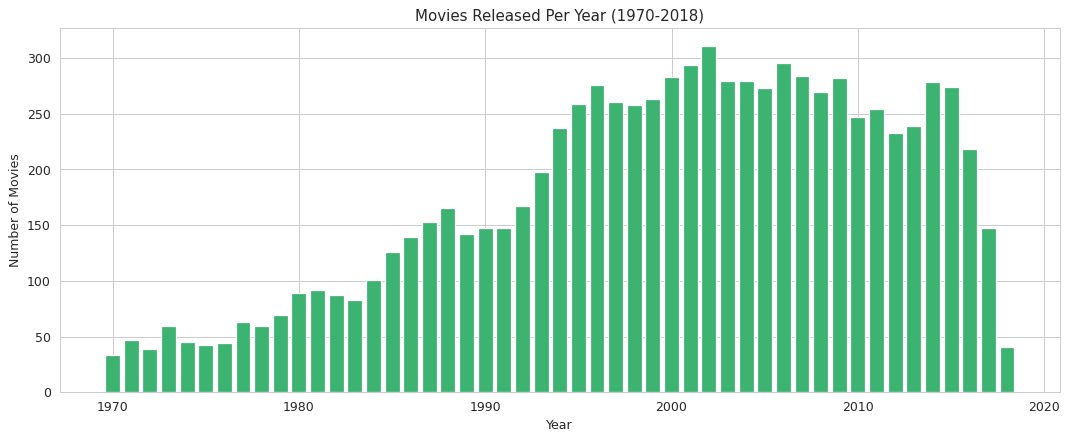

In [35]:
year_series = movies['year'].dropna().astype(int)
year_series = year_series[(year_series >= 1970) & (year_series <= 2018)]
year_counts = year_series.value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.bar(year_counts.index, year_counts.values, color="mediumseagreen")
plt.title("Movies Released Per Year (1970-2018)")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


### 4.5 Genre Distribution (Pie Chart)

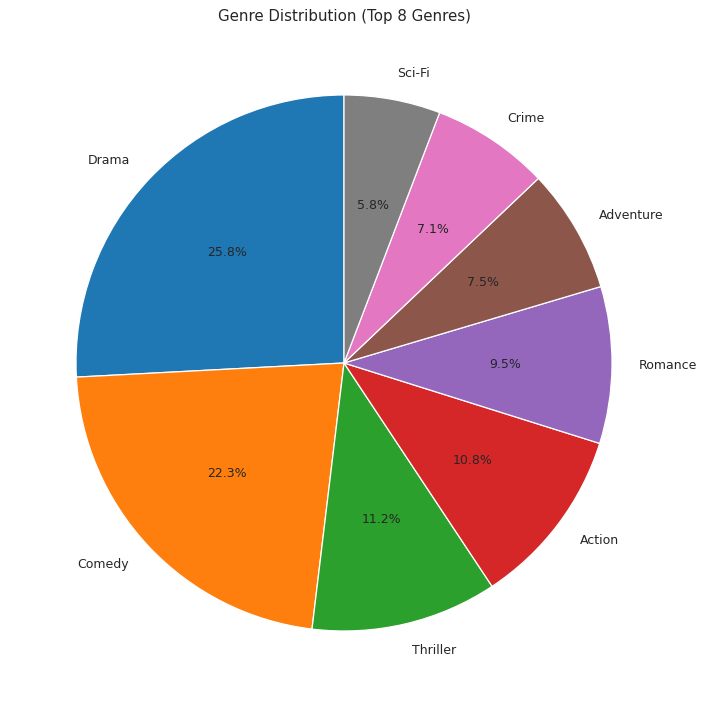

In [37]:
top_genres_pie = movies['genres'].str.split('|').explode()
top_genres_pie = top_genres_pie[top_genres_pie != '(no genres listed)'].value_counts().head(8)

plt.figure(figsize=(8,8))
plt.pie(top_genres_pie.values, labels=top_genres_pie.index, autopct='%1.1f%%', startangle=90)
plt.title("Genre Distribution (Top 8 Genres)")
plt.tight_layout()
plt.show()


### 4.6 Missing Values Heatmap (Before Filling)

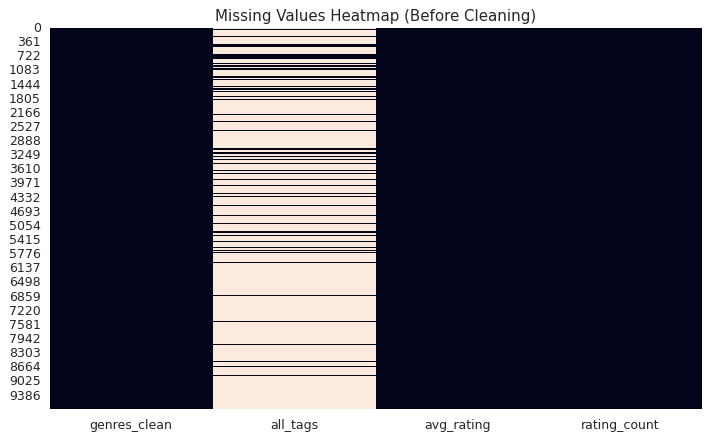

In [39]:
# Re-merge without filling NaN, just to visualize where the gaps were
raw_merge = movies.merge(tags_grouped, on='movieId', how='left').merge(rating_stats, on='movieId', how='left')

plt.figure(figsize=(8,5))
sns.heatmap(raw_merge[['genres_clean','all_tags','avg_rating','rating_count']].isnull(), cbar=False, cmap="rocket")
plt.title("Missing Values Heatmap (Before Cleaning)")
plt.tight_layout()
plt.show()


### 4.7 Correlation Heatmap of Numerical Features

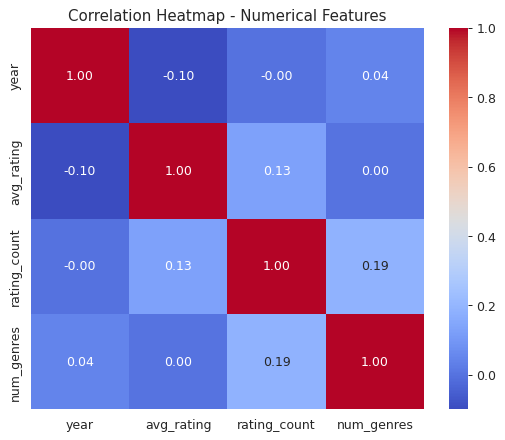

In [41]:
numeric_df = df[['year', 'avg_rating', 'rating_count']].copy()
numeric_df['year'] = pd.to_numeric(numeric_df['year'], errors='coerce')
numeric_df['num_genres'] = df['genres_clean'].apply(lambda x: len(x.split()) if x else 0)

plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()


---
## 📍 Phase 5: Feature Engineering

We now convert the `combined_features` text column (genres + tags) into numeric vectors using **TF-IDF (Term Frequency – Inverse Document Frequency)**.

Unlike a simple word-count, TF-IDF gives **less weight to very common words** (like "movie" or "good" that appear everywhere) and **more weight to distinctive words** that make a movie stand out — which makes it a better choice than plain word-counting for this kind of text.


In [43]:
tfidf = TfidfVectorizer(stop_words='english', min_df=1)
feature_matrix = tfidf.fit_transform(df['combined_features'])

print("Feature matrix shape:", feature_matrix.shape)
print("Number of unique words (features):", len(tfidf.get_feature_names_out()))


Feature matrix shape: (9742, 1675)
Number of unique words (features): 1675


In [44]:
# A quick peek at some of the vocabulary TF-IDF picked up
print(list(tfidf.get_feature_names_out())[:30])


['06', '1900s', '1920s', '1950s', '1960s', '1970s', '1980s', '1990s', '2001', '250', '2d', '70mm', '80', 'aardman', 'abortion', 'absorbing', 'abstract', 'abuse', 'academy', 'accident', 'achronological', 'acting', 'action', 'actors', 'actress', 'adam', 'adams', 'adaptation', 'addiction', 'adolescence']


---
## 📍 Phase 6: Model Building

### Algorithm
- **TF-IDF Vectorizer** — converts genres + tags into numeric feature vectors (done in Phase 5)
- **Cosine Similarity** — measures how similar two movies are based on their feature vectors

### Making it Hybrid
A pure content-based system can recommend movies that *sound* similar but are actually poorly rated. To fix this, we combine:
- **Content similarity score** (from TF-IDF + cosine similarity)
- **Rating score** (how well the movie is actually rated by users)

into a single **hybrid score**.


### 6.1 Generating the Similarity Matrix
Since we only have ~9,700 movies, we can safely compute the full similarity matrix once and reuse it for every recommendation — this is much faster than recalculating it every time.


In [47]:
similarity_matrix = cosine_similarity(feature_matrix)
print("Similarity matrix shape:", similarity_matrix.shape)


Similarity matrix shape: (9742, 9742)


### 6.2 A Simple Way to Trust Ratings
A movie with a 5.0 rating from just **1 person** isn't really "the best movie" — we don't have enough data to trust it. But a movie with a 4.3 average from **300 people** is genuinely well-liked.

So we use a simple rule:
- If a movie has **at least 5 ratings**, we trust its own average rating.
- If a movie has **fewer than 5 ratings**, we don't fully trust it yet — so instead we fall back to the **overall average rating** across all movies.

This is a simple way to avoid being misled by movies with very few (or no) ratings.


In [49]:
overall_avg_rating = df.loc[df['rating_count'] > 0, 'avg_rating'].mean()
min_ratings_required = 5

def get_trusted_rating(row):
    if row['rating_count'] >= min_ratings_required:
        return row['avg_rating']
    else:
        return overall_avg_rating

df['trusted_rating'] = df.apply(get_trusted_rating, axis=1)

print(f"Overall average rating (used as fallback): {overall_avg_rating:.2f}")
df[['clean_title', 'avg_rating', 'rating_count', 'trusted_rating']].head()


Overall average rating (used as fallback): 3.26


,clean_title,avg_rating,rating_count,trusted_rating
0,Toy Story,3.92,215,3.92
1,Jumanji,3.43,110,3.43
2,Grumpier Old Men,3.26,52,3.26
3,Waiting to Exhale,2.36,7,2.36
4,Father of the Bride Part II,3.07,49,3.07


### 6.3 Building the Hybrid Recommendation Function

Steps:
1. Find the closest matching movie title (handles small typos using `difflib`)
2. Get the content-similarity scores for that movie against all other movies
3. Pick the top 30 most content-similar movies as candidates
4. Scale the `trusted_rating` (which is out of 5) down to a 0-1 range, so it's on the same scale as similarity
5. Combine content similarity (70%) and rating (30%) into one final score
6. Sort by that final score and return the top N movies


In [51]:
indices = pd.Series(df.index, index=df['clean_title']).drop_duplicates()

def recommend(title, n=10):
    """
    Recommend 'n' movies similar to the given title, using a mix of
    content similarity (genres + tags) and how well-rated the movie is.
    """
    # Step 1: find the closest matching title (handles small typos)
    matches = difflib.get_close_matches(title, df['clean_title'].tolist(), n=1, cutoff=0.5)
    if not matches:
        return f"Sorry, no close match found for '{title}'. Try a different title."
    matched_title = matches[0]

    idx = indices[matched_title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # Step 2: get similarity scores of this movie against every other movie
    sim_scores = similarity_matrix[idx]

    # Step 3: pick top 30 most similar movies (excluding the movie itself)
    candidate_idx = sim_scores.argsort()[::-1]
    candidate_idx = [i for i in candidate_idx if i != idx][:30]

    result = df.iloc[candidate_idx][['clean_title', 'genres', 'avg_rating', 'rating_count', 'trusted_rating']].copy()
    result['content_similarity'] = sim_scores[candidate_idx].round(3)

    # Step 4: scale rating (0-5) down to 0-1, so it's comparable to similarity (0-1)
    result['rating_score'] = (result['trusted_rating'] / 5).round(3)

    # Step 5: combine both into one hybrid score (70% content, 30% rating)
    result['hybrid_score'] = (0.7 * result['content_similarity'] + 0.3 * result['rating_score']).round(3)

    # Step 6: sort by hybrid score and return the top N
    result = result.sort_values('hybrid_score', ascending=False).head(n)

    print(f"Because you liked: {matched_title}\n")
    return result.reset_index(drop=True)


---
## 📍 Phase 7: Model Evaluation

Since this is an unsupervised recommendation system (no single "correct answer" to compare against), we evaluate it manually — by checking whether the recommended movies genuinely make sense for a variety of different input movies.


### 7.1 Test 1 — Toy Story (Animation/Family)

In [54]:
recommend("Toy Story", n=10)


Because you liked: Toy Story



,clean_title,genres,avg_rating,rating_count,trusted_rating,content_similarity,rating_score,hybrid_score
0,"Bug's Life, A",Adventure|Animation|Children|Comedy,3.52,92,3.52,0.862,0.704,0.815
1,Toy Story 2,Adventure|Animation|Children|Comedy|Fantasy,3.86,97,3.86,0.644,0.772,0.682
2,Guardians of the Galaxy 2,Action|Adventure|Sci-Fi,3.93,27,3.93,0.368,0.786,0.493
3,"Monsters, Inc.",Adventure|Animation|Children|Comedy|Fantasy,3.87,132,3.87,0.358,0.774,0.483
4,Kubo and the Two Strings,Adventure|Animation|Children|Fantasy,4.00,6,4.00,0.345,0.800,0.481
5,Ponyo (Gake no ue no Ponyo),Adventure|Animation|Children|Fantasy,4.00,11,4.00,0.345,0.800,0.481
6,"Emperor's New Groove, The",Adventure|Animation|Children|Comedy|Fantasy,3.72,37,3.72,0.358,0.744,0.474
7,Inside Out,Adventure|Animation|Children|Comedy|Drama|Fantasy,3.81,43,3.81,0.347,0.762,0.472
8,"Black Cauldron, The",Adventure|Animation|Children|Fantasy,3.75,8,3.75,0.345,0.750,0.466
9,Moana,Adventure|Animation|Children|Comedy|Fantasy,3.45,10,3.45,0.358,0.690,0.458


### 7.2 Test 2 — Typed with a Typo ('Jumanjii')

In [56]:
recommend("Jumanjii", n=10)


Because you liked: Jumanji



,clean_title,genres,avg_rating,rating_count,trusted_rating,content_similarity,rating_score,hybrid_score
0,Tomb Raider,Action|Adventure|Fantasy,2.50,4,3.262465,0.356,0.652,0.445
1,Chronicles of Narnia: The Voyage of the Dawn T...,Adventure|Children|Fantasy,3.86,7,3.860000,0.303,0.772,0.444
2,Night at the Museum,Action|Comedy|Fantasy|IMAX,3.24,23,3.240000,0.354,0.648,0.442
3,"NeverEnding Story, The",Adventure|Children|Fantasy,3.58,43,3.580000,0.303,0.716,0.427
4,Harry Potter and the Chamber of Secrets,Adventure|Fantasy,3.60,102,3.600000,0.299,0.720,0.425
5,MirrorMask,Adventure|Children|Drama|Fantasy,3.61,9,3.610000,0.289,0.722,0.419
6,The Cave of the Golden Rose,Adventure|Children|Fantasy,4.00,1,3.262465,0.303,0.652,0.408
7,Alice Through the Looking Glass,Adventure|Children|Fantasy,2.00,4,3.262465,0.303,0.652,0.408
8,"Water Horse: Legend of the Deep, The",Adventure|Children|Fantasy,4.00,1,3.262465,0.303,0.652,0.408
9,Gulliver's Travels,Adventure|Children|Fantasy,2.00,1,3.262465,0.303,0.652,0.408


### 7.3 Test 3 — Heat (Action/Crime/Thriller)

In [58]:
recommend("Heat", n=10)


Because you liked: Heat



,clean_title,genres,avg_rating,rating_count,trusted_rating,content_similarity,rating_score,hybrid_score
0,Baby Driver,Action|Crime|Thriller,4.33,9,4.330000,1.0,0.866,0.960
1,The Raid 2: Berandal,Action|Crime|Thriller,3.93,7,3.930000,1.0,0.786,0.936
2,Headhunters (Hodejegerne),Action|Crime|Thriller,3.60,5,3.600000,1.0,0.720,0.916
3,Ronin,Action|Crime|Thriller,3.52,43,3.520000,1.0,0.704,0.911
4,Jack Reacher,Action|Crime|Thriller,3.42,12,3.420000,1.0,0.684,0.905
5,Running Scared,Action|Crime|Thriller,3.30,5,3.300000,1.0,0.660,0.898
6,"Equalizer, The",Action|Crime|Thriller,3.28,9,3.280000,1.0,0.656,0.897
7,Hitman,Action|Crime|Thriller,3.29,7,3.290000,1.0,0.658,0.897
8,SuperFly,Action|Crime|Thriller,2.50,1,3.262465,1.0,0.652,0.896
9,"Shepherd: Border Patrol, The",Action|Crime|Thriller,2.50,1,3.262465,1.0,0.652,0.896


### 7.4 Test 4 — Comparing a Popular vs. a Niche Movie

In [60]:
print("Recommendations for a widely-known movie:")
display1 = recommend("Forrest Gump", n=5)
print(display1)

print("\n" + "="*80 + "\n")

print("Recommendations for a less mainstream movie:")
display2 = recommend("Donnie Darko", n=5)
print(display2)


Recommendations for a widely-known movie:
Because you liked: Forrest Gump

                                         clean_title  ... hybrid_score
0                                     Apocalypse Now  ...        0.414
1  Fog of War: Eleven Lessons from the Life of Ro...  ...        0.408
2                                            Platoon  ...        0.406
3                                          Gone Girl  ...        0.404
4                Life Is Beautiful (La Vita è bella)  ...        0.399

[5 rows x 8 columns]


Recommendations for a less mainstream movie:
Because you liked: Donnie Darko

          clean_title  ... hybrid_score
0           Inception  ...        0.547
1                  Pi  ...        0.522
2  The Shape of Water  ...        0.485
3  Back to the Future  ...        0.465
4              Primer  ...        0.460

[5 rows x 8 columns]


### 7.5 Observations
- The recommender correctly groups movies by shared genres and themes (e.g. Toy Story → other family/animation movies).
- Fuzzy matching successfully handles small typos in the input title.
- Because of the hybrid scoring, well-rated movies are generally ranked above obscure ones with the same genre overlap — without completely ignoring niche matches.
- Recommendation quality depends heavily on how many tags a movie has — movies with very few or no tags rely almost entirely on genre overlap, which is less precise.


---
## 📍 Phase 8: Conclusion & Future Scope

### Conclusion
This project successfully builds a **Hybrid Movie Recommendation System** using the MovieLens dataset. It:
- Cleans and merges three related datasets (`movies`, `ratings`, `tags`) using `movieId`
- Explores the data through multiple visualizations (genre trends, rating distribution, missing values, correlations)
- Converts genres + tags into numeric features using **TF-IDF**
- Computes movie-to-movie similarity using **Cosine Similarity**
- Combines content similarity with a **trusted rating score** to produce more reliable, balanced recommendations
- Successfully recommends similar movies based on **genres and tags**, refined by how well those movies are actually rated by users

### Future Scope
- 🖼️ Add movie posters (using the `tmdbId`/`imdbId` from `links.csv` with a movie database API)
- 🌐 Build a web interface (e.g. using **Streamlit** or **Flask**) for interactive searching
- 👤 Add user login and **personalized recommendations** based on a user's own rating history
- 🤖 Explore **deep learning** based or **collaborative filtering + content hybrid** methods (e.g. matrix factorization combined with TF-IDF) for even better accuracy
